# Nesso-1 on 150 Runs N' Poses systems

## Question

Does Nesso-1's protein--ligand structural representation become less accurate
when a complex is unlike structures available before its September 2021
training cutoff?

We combine all **150 systems** into one analysis. Nesso received only protein
sequence and ligand SMILES. Experimental coordinates were introduced only
after inference to evaluate predicted distance distributions, contacts, and
pocket residues.

> This is a structural benchmark. Runs N' Poses does not provide systematic
> experimental affinity labels for these systems.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def repository_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "reports").is_dir() and (candidate / "configs").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside BindingAffinityPredictor")


ROOT = repository_root(Path.cwd())
RESULTS = ROOT / "reports/exp014_nesso1_rnp_combined150/results"
summary = json.loads((RESULTS / "summary.json").read_text())
systems = pd.read_csv(RESULTS / "per_system_metrics.csv")
aggregate = summary["aggregate"]

assert len(systems) == 150
assert systems["sample_id"].nunique() == 150
assert aggregate["systems_failed"] == 0

{
    "systems": len(systems),
    "scoring_failures": aggregate["systems_failed"],
    "bootstrap_unit": aggregate["bootstrap"]["unit"],
}


/home/yusheng/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/yusheng/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


{'systems': 150,
 'scoring_failures': 0,
 'bootstrap_unit': "Runs N' Poses cluster (all records in a sampled cluster retained)"}

## Metrics

- **Distogram NLL:** probability assigned to the experimentally observed
  protein--ligand distance bins. Lower is better.
- **Distance MAE:** error in expected protein-token--ligand-atom distances, in
  Å. Lower is better.
- **Contact AP:** ranking quality for 6 Å protein-token--ligand contacts.
  Higher is better.
- **Pocket F1:** overlap between predicted and experimental 6 Å pocket
  residues. Higher is better.
- **Spearman $\rho$:** monotonic rank association with familiarity. Therefore,
  favorable familiarity trends are negative for errors and positive for
  accuracy metrics.


In [2]:
metrics = {
    "Distogram NLL ↓": "interface_distogram_nll",
    "Distance MAE ↓": "interface_expected_distance_mae_angstrom",
    "Contact AP ↑": "token_contact_average_precision_at_6a",
    "Contact AUROC ↑": "token_contact_auroc_at_6a",
    "Pocket F1 ↑": "physical_pocket_f1_at_6a",
}
rows = []
for label, metric in metrics.items():
    result = aggregate["spearman_vs_familiarity"][metric]
    rows.append({
        "Metric": label,
        "Spearman rho": result["rho"],
        "95% CI lower": result["lower_95"],
        "95% CI upper": result["upper_95"],
    })
rho_table = pd.DataFrame(rows).set_index("Metric")
display(rho_table.style.format("{:+.3f}"))


,Spearman rho,95% CI lower,95% CI upper
Metric,,,
Distogram NLL ↓,-0.651,-0.749,-0.529
Distance MAE ↓,-0.686,-0.781,-0.571
Contact AP ↑,+0.649,+0.517,+0.752
Contact AUROC ↑,+0.625,+0.491,+0.736
Pocket F1 ↑,+0.638,+0.508,+0.734


All intervals exclude zero. Across the 150 systems, greater structural
familiarity is consistently associated with smaller distance errors and
better contact and pocket recovery.


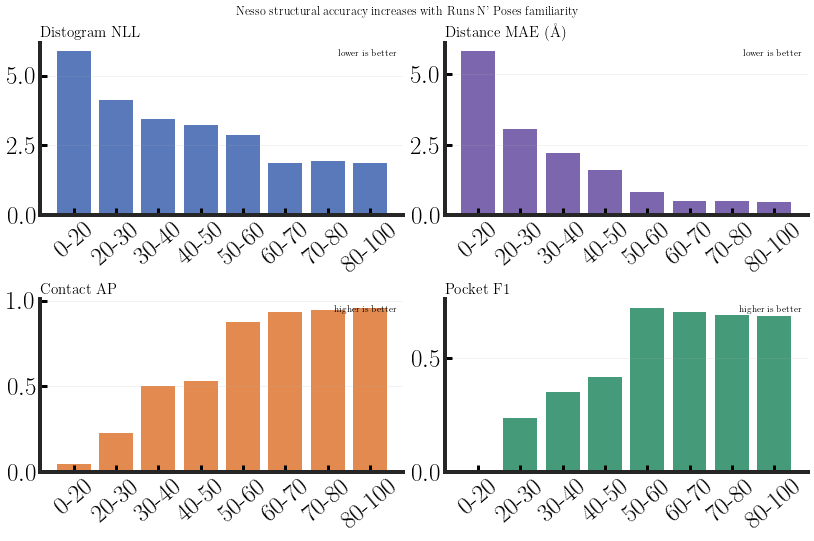

In [3]:
bins = ["0-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-100"]
panels = [
    ("interface_distogram_nll", "Distogram NLL", "lower is better", "#4267B2"),
    ("interface_expected_distance_mae_angstrom", "Distance MAE (Å)", "lower is better", "#6A51A3"),
    ("token_contact_average_precision_at_6a", "Contact AP", "higher is better", "#E07A38"),
    ("physical_pocket_f1_at_6a", "Pocket F1", "higher is better", "#2B8C68"),
]
fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.4), constrained_layout=True)
for ax, (metric, title, direction, color) in zip(axes.flat, panels):
    values = [aggregate["by_familiarity_bin"][b]["metrics"][metric]["median"] for b in bins]
    ax.bar(bins, values, color=color, alpha=0.88)
    ax.set_title(title, loc="left", weight="bold")
    ax.text(0.98, 0.96, direction, transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.tick_params(axis="x", rotation=40)
    ax.grid(axis="y", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Nesso structural accuracy increases with Runs N' Poses familiarity", weight="bold")
plt.show()


The unfamiliar 0--20 bin has median distance MAE 5.83 Å and median pocket F1
of zero. Above familiarity 50, median distance MAE is below 1 Å and median
contact AP exceeds 0.87. Individual bars need not improve monotonically; the
rank correlation uses all 150 continuous familiarity values.


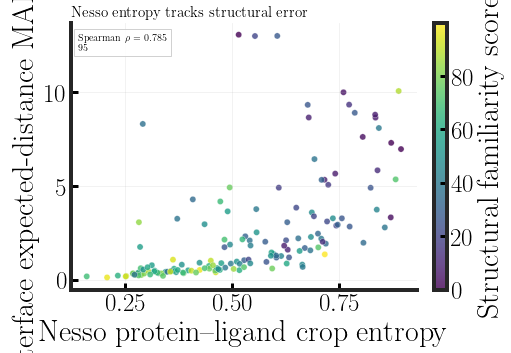

In [4]:
entropy_result = aggregate["entropy_error_spearman"]["interface_expected_distance_mae_angstrom"]
fig, ax = plt.subplots(figsize=(7.0, 4.8), constrained_layout=True)
points = ax.scatter(
    systems["entropy_crop_pl"],
    systems["interface_expected_distance_mae_angstrom"],
    c=systems["familiarity_score_0_to_100"],
    cmap="viridis",
    s=38,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.35,
)
ax.set_title("Nesso entropy tracks structural error", loc="left", weight="bold")
ax.set_xlabel("Nesso protein–ligand crop entropy")
ax.set_ylabel("Interface expected-distance MAE (Å)")
ax.text(
    0.02, 0.96,
    f"Spearman $\\rho$ = {entropy_result['rho']:.3f}\n"
    f"95% CI [{entropy_result['lower_95']:.3f}, {entropy_result['upper_95']:.3f}]",
    transform=ax.transAxes,
    va="top",
    bbox={"facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.9},
)
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
fig.colorbar(points, ax=ax, label="Structural familiarity score")
plt.show()


## Combined conclusion

Across all 150 systems:

- familiarity versus distance MAE: $\rho=-0.686$;
- familiarity versus contact AP: $\rho=+0.649$;
- familiarity versus pocket F1: $\rho=+0.638$;
- Nesso entropy versus distance MAE: $\rho=+0.785$.

Nesso's distance representation is substantially more reliable on familiar
complexes, and its entropy provides a useful warning signal when that
representation is inaccurate. These associations do not by themselves prove
literal memorization or measure binding affinity.
